<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymemu-002-dynamics-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gymnasium - Gameplay Frame Latent Compression with Autoencoder - Part 2 - Train Dynamics Model

In [1]:
# TODO: load processed dataset

In [2]:
!pip install wandb datasets tsilva_notebook_utils==0.0.55

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and

In [3]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random nb_seed used for reproducibility across runs
    nb_seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID to load gameplay recordings from
    ds_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"  # @param {type: "string"}
    # @markdown Whether to deduplicate frames
    ds_dedupe_frames = True  # @param {type: "boolean"}
    # @markdown Number of frames to skip between inputs
    ds_frame_skip = 4  # @param {type: "integer"}
    # @markdown Scale factor for input image resizing
    ds_image_scale = 1.0  # @param {type: "number"}
    # @markdown Image mode used
    ds_image_mode = "grayscale"  # @param ["color", "grayscale", "black_and_white"]
    # @markdown Number of colors when quantizing (for black-and-white mode)
    ds_image_quantize_colors = 0  # @param {type: "integer"}
    # @markdown Crop paddings (left, top, right, bottom)
    ds_image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    # @markdown ### 🏋️️ Training Image Augmentation Settings

    # @markdown ### 🧠 Model Settings

    # @markdown Compile model
    model_compile = True  # @param {type: "boolean"}
    # @markdown Dimensionality of the learned latent space
    model_latent_dim = 16  # @param {type: "integer"}
    # @markdown Noise added to the latent representation
    model_latent_noise_factor = 0.0  # @param {type: "number"}
    # @markdown Small constant for latent computations
    model_latent_sparsity_epsilon = 1e-3  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Total number of training epochs
    train_n_epochs = 100  # @param {type: "integer"}
    # @markdown Number of samples per batch
    train_batch_size = 128  # @param {type: "integer"}
    # @markdown Maximum gradient norm for clipping
    train_max_grad_norm = 0  # @param {type: "number"}
    # @markdown L2 weight decay for optimizer
    train_weight_decay = 0  # @param {type: "number"}
    # @markdown Proportion of steps for learning rate warmup
    train_warmup_ratio = 0  # @param {type: "number"}
    # @markdown Loss function used
    train_loss_function = "l1"  # @param ["l1", "mse"]
    # @markdown Weight for sparsity loss
    train_latent_sparsity_loss_alpha = 0.0  # @param {type: "number"}
    # @markdown Optimizer learning rate
    train_learning_rate = 0.001  # @param {type: "number"}
    # @markdown  train_drift amount during training on reconstructions
    train_drift = 1  # @param {type: "integer"}
    # @markdown Number of epochs between validations
    val_epochs = 10  # @param {type: "integer"}

    # Set notebook ID in the environment
    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook
        nb_seed=nb_seed,

        # Dataset
        ds_id=ds_id,
        ds_dedupe_frames=ds_dedupe_frames,
        ds_frame_skip=ds_frame_skip,
        ds_image_scale=ds_image_scale,
        ds_image_mode=ds_image_mode,
        ds_image_quantize_colors=ds_image_quantize_colors,
        ds_image_crop_paddings=ds_image_crop_paddings,

        # Model
        model_compile=model_compile,
        model_latent_dim=model_latent_dim,
        model_latent_noise_factor=model_latent_noise_factor,
        model_latent_sparsity_epsilon=model_latent_sparsity_epsilon,

        # Training
        train_n_epochs=train_n_epochs,
        train_batch_size=train_batch_size,
        train_max_grad_norm=train_max_grad_norm,
        train_weight_decay=train_weight_decay,
        train_warmup_ratio=train_warmup_ratio,
        train_loss_function=train_loss_function,
        train_learning_rate=train_learning_rate,
        train_latent_sparsity_loss_alpha=train_latent_sparsity_loss_alpha,
        train_drift=train_drift,
        val_epochs=val_epochs
    )

CONFIG = setup_config()

In [4]:
from datasets import load_dataset
raw_dataset = load_dataset(CONFIG["ds_id"], split="train")
raw_dataset

README.md:   0%|          | 0.00/389 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

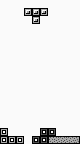

In [5]:
from tsilva_notebook_utils.datasets import process_images
from torchvision.transforms.functional import to_pil_image

PROCESS_IMAGE_CONFIG = {
    "mode" : CONFIG["ds_image_mode"],
    "quantize_colors" : CONFIG["ds_image_quantize_colors"],
    "scale" : CONFIG["ds_image_scale"],
    "crop_paddings" : [int(x) for x in CONFIG["ds_image_crop_paddings"].split(",")]
}
processed_image_t = process_images([raw_dataset[400]["image"]], **PROCESS_IMAGE_CONFIG)[0]
processed_image = to_pil_image(processed_image_t)
processed_image

In [6]:
from tsilva_notebook_utils.datasets import dedupe_dataset
deduped_dataset = dedupe_dataset(raw_dataset, "image") if CONFIG["ds_dedupe_frames"] else raw_dataset.map(lambda x:x, batched=True)
deduped_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

In [7]:
def _map_process_images(batch):
    xs = process_images(batch["image"], **PROCESS_IMAGE_CONFIG)
    return dict(x=xs, y=xs)

processed_dataset = deduped_dataset.map(
    _map_process_images,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

In [8]:
processed_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step'])

In [9]:
processed_dataset = processed_dataset.with_format("torch")

In [10]:
processed_image_t =processed_dataset[0]["x"]

In [11]:
image_channels, image_height, image_width = processed_image_t.shape
image_channels, image_height, image_width

(1, 144, 80)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from tsilva_notebook_utils.torch import get_current_device

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, model_latent_dim=None, use_bottleneck=True):
        super(ConvAutoencoder, self).__init__()

        self.model_latent_noise_factor = CONFIG['model_latent_noise_factor']

        if model_latent_dim is None: model_latent_dim = CONFIG['model_latent_dim']
        self.use_bottleneck = use_bottleneck

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_bottleneck:
            self.fc_enc = nn.Linear(self._flattened_size, model_latent_dim)
            self.fc_dec = nn.Linear(model_latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_bottleneck:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_bottleneck:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        z_input = z

        # Add noise to latent space
        if self.training and self.model_latent_noise_factor > 0:
            noise = torch.randn_like(z_input) * self.model_latent_noise_factor
            z_input += noise

        out = self.decode(z_input)
        return out, z

model_latent_dim = CONFIG['model_latent_dim']
use_bottleneck = model_latent_dim > 0
input_channels = image_channels
output_channels = image_channels
device = get_current_device()
representation_model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck).to(device)
representation_model = torch.compile(representation_model) if CONFIG["model_compile"] else representation_model
representation_model

OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_enc): Linear(in_features=23040, out_features=16, bias=True)
    (fc_dec): Linear(in_features=16, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2

In [13]:
from torch.utils.data import IterableDataset, DataLoader
dataloader = DataLoader(processed_dataset, batch_size=8)

for batch in dataloader:
    print(type(batch["x"][0]))
    break

<class 'torch.Tensor'>


In [14]:
from tsilva_notebook_utils.video import render_video_from_dataloader
render_video_from_dataloader(dataloader, scale=2)

In [15]:
#from tsilva_notebook_utils.datasets import ShiftedDataset

from datasets import Dataset

import torch

# TODO: move to utisl
# TODO: softcode dataset so that we only specify which features to shift and all others are the same
# TODO: preserve info functionality
class ShiftedDataset(Dataset):
    def __init__(self, base_dataset, shift=1):
        if shift < 1:
            raise ValueError("Shift must be >= 1")
        self.base_dataset = base_dataset
        self.shift = shift

    def __len__(self):
        return len(self.base_dataset) - self.shift

    def __getitem__(self, idx):
        if isinstance(idx, (list, torch.Tensor)):
            # batch: collect into dict of lists
            batch = {"x": [], "y": [], "action" : []}
            for i in idx:
                item = self._get_single_item(int(i))
                batch["x"].append(item["x"])
                batch["y"].append(item["y"])
                batch["action"].append(item["action"])
            return batch
        else:
            return self._get_single_item(idx)

    def _get_single_item(self, idx):
        if idx < 0 or idx >= len(self):
            raise IndexError("Index out of range")
        x = self.base_dataset[idx]
        y = self.base_dataset[idx + self.shift]
        return {"x": x.get("x"), "action": x.get("action"), "y": y.get("y")}



lazy_dataset = ShiftedDataset(processed_dataset, shift=5)
shifted_dataloader = DataLoader(lazy_dataset, batch_size=8)
render_video_from_dataloader(shifted_dataloader, scale=2)

In [16]:
processed_dataset

Dataset({
    features: ['action', 'x', 'y'],
    num_rows: 5012
})

In [17]:
shifted_dataloader

In [18]:
from huggingface_hub import hf_hub_download

# Replace with your model repo and filename
ds_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"
model_path = hf_hub_download(
    repo_id=f"{ds_id}-autoencoder",  # e.g., "facebook/wav2vec2-base-960h"
    filename="model.pt",                # the file inside the repo
)

print(f"Model downloaded to: {model_path}")

# Now load the state dict
state_dict = torch.load(model_path, map_location="cpu")  # or "cuda" if you want to directly load onto GPU

# Load the weights into your model
representation_model.load_state_dict(state_dict)

# Set model to evaluation mode if you're going to use it for inference
representation_model.eval()
# Load it with torch if needed
#import torch
#model = torch.load(model_path)


model.pt:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/models--tsilva--GymnasiumRecording__Tetris_GameBoy-autoencoder/snapshots/bee7def1f74ca1aaf98a4129af350cb82b212d39/model.pt


OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_enc): Linear(in_features=23040, out_features=16, bias=True)
    (fc_dec): Linear(in_features=16, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2

In [19]:
representation_model

OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_enc): Linear(in_features=23040, out_features=16, bias=True)
    (fc_dec): Linear(in_features=16, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2

In [20]:
render_video_from_dataloader(dataloader, model=representation_model, scale=2)

/usr/local/lib/python3.11/dist-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0425 15:49:50.855000 2167 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


In [21]:
import torch
import torch.nn as nn
from tsilva_notebook_utils.torch import get_model_device

class DynamicsModel(nn.Module):
    def __init__(self):
        super(DynamicsModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(16 + 9, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
            # TODO: check how bottleneck is encoded
        )

    def forward(self, x):
        return self.model(x)

device = get_model_device(representation_model)
dynamics_model = DynamicsModel().to(device)

- TODO: create dataset with representaiton model
- TODO: shuffle the dataloader

In [22]:
import multiprocessing
from tsilva_notebook_utils.torch import get_model_device
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Define loss function
loss_fn = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(dynamics_model.parameters(), lr=1e-3)

# Define number of epochs
num_epochs = 10

train_loader = DataLoader(
    lazy_dataset,
    batch_size=512,
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

# Training loop

representation_model.eval()
dynamics_model.train()

# Freeze the representation model
for param in representation_model.parameters():
    param.requires_grad = False

for epoch in range(num_epochs):
    pbar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False)
    epoch_losses = []
    for batch in pbar:
        xs = batch['x'].to(device)
        actions = batch['action'].to(device)
        ys = batch['y'].to(device)

        optimizer.zero_grad()

        # Encode inputs
        with torch.no_grad():
            x_z = representation_model.encode(xs)
            y_z = representation_model.encode(ys)

        # Predict next latent state
        x_z_actions = torch.cat([x_z, actions], dim=1)
        pred_z = dynamics_model(x_z_actions)

        # Compute loss
        loss = loss_fn(pred_z, y_z)
        epoch_losses.append(loss.item())

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Update progress bar with loss
        pbar.set_postfix({'batch_loss': loss.item()})

    epoch_loss = sum(epoch_losses) / len(epoch_losses)
    pbar.set_postfix({"epoch_loss" : epoch_loss})

In [23]:
from tsilva_notebook_utils.video import render_video_from_batches

representation_model.eval()
dynamics_model.eval()
with torch.no_grad():
    # TODO: must run this with test loader
    ys_frames = []
    pred_ys_frames = []
    for batch in shifted_dataloader:
      xs = batch['x'].to(device)
      actions = batch['action'].to(device)
      ys = batch['y'].to(device)
      xs_zs = representation_model.encode(xs)
      xs_zs_actions = torch.cat([xs_zs, actions], dim=1)
      pred_zs = dynamics_model(xs_zs_actions)
      pred_ys = representation_model.decode(pred_zs)
      for y_i, pred_y_i in zip(ys, pred_ys):
        ys_frames.append(to_pil_image(y_i))
        pred_ys_frames.append(to_pil_image(pred_y_i))

In [24]:
ys_html = render_video_from_batches(ys_frames)
ys_html

In [25]:
pred_ys_html = render_video_from_batches(pred_ys_frames)
pred_ys_html

In [26]:
from IPython.display import HTML

combined_html = HTML(f'''
<div style="display: flex; gap: 10px;">
    {ys_html.data}
    {pred_ys_html.data}
</div>
''')

display(combined_html)